In [1]:
import pandas as pd
import os

In [2]:
train_results_dir = os.path.join('results_shipsnet_new_uniform','results_shipsnet_v02_01')

In [3]:
import os

In [4]:
search_dir = os.path.join('results_shipsnet_new_uniform','results_shipsnet_v02_01')
#list all .json files in the directory
all_files = [f for f in os.listdir(search_dir)]
json_files = [f for f in os.listdir(search_dir) if f.endswith('.json')]

# excluding the format, get the last 16 characters of each filename
timestamps = [f[:-5][-16:] for f in json_files]
print("Timestamps found count:", len(timestamps))

# remove some timestamps that are not needed
# those are the ones that are not in the shipsnet_seu_result directory, without the .csv extension
#excluded_timestamps = [f[:-4][-16:] for f in [f for f in os.listdir('shipsnet_newslate_seu_result') if f.endswith('.csv')]]

#timestamps = [ts for ts in timestamps if ts not in excluded_timestamps]
#timestamps = timestamps[:1]
#print("After excluding, timestamps count:", len(timestamps))

Timestamps found count: 63


In [5]:
config_files = {}
guide_files = {}
model_files = {}
param_files = {}

for timestamp in timestamps:
    config_files[timestamp] = [f for f in all_files if timestamp in f and f.endswith('.json')][0]
    guide_files[timestamp] = [f for f in all_files if timestamp in f and f.startswith('guide')][0]
    model_files[timestamp] = [f for f in all_files if timestamp in f and f.startswith('model')][0]
    param_files[timestamp] = [f for f in all_files if timestamp in f and f.startswith('param')][0]

In [6]:
ts_idx = 0

In [7]:
import json

def load_model_config(timestamp):
    config_path = os.path.join(search_dir, config_files[timestamp])

    with open(config_path, 'r') as f:
        model_config = json.load(f)

    return model_config

In [8]:
model_config = load_model_config(timestamps[ts_idx])

In [9]:
model_config

{'activation': 'actRWG',
 'prior': 'gaussian',
 'num_epochs': 100,
 'best_accuracy_at_epoch': 90,
 'best_accuracy': 0.6453125,
 'batch_size': 16,
 'train_size': 3200,
 'prior_params': {'mu': 0.0, 'b': 10.0}}

## Distribution comparison

In [ ]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt

def plot_priors(mu, b, x_min=None, x_max=None, num_points=1000):
    """
    Plot the PDFs of three priors centered at mu with scale b:
      • Gaussian(μ, b)
      • Laplace(μ, b)
      • Uniform(–b, b)
    
    Parameters
    ----------
    mu : float
        Location parameter for Gaussian and Laplace.
    b : float
        Scale parameter for Gaussian and Laplace; half‐width for Uniform.
    x_min, x_max : float, optional
        Min/max of x‐axis. If None, they default to μ±5b.
    num_points : int
        Number of points to plot on the x‐axis.
    """
    # 1) Define the two torch distributions
    gaussian = dist.Normal(mu, b)
    laplace  = dist.Laplace(mu, b)

    # 2) Create x‐axis
    if x_min is None or x_max is None:
        x_min = mu - 5*b
        x_max = mu + 5*b
    x = torch.linspace(x_min, x_max, num_points)

    # 3) Compute PDFs
    p_gauss   = torch.exp(gaussian.log_prob(x))
    p_laplace = torch.exp(laplace.log_prob(x))
    # Manual Uniform PDF: 1/(2b) on [–b, b], else 0
    p_uniform = torch.where(
        (x >= mu - b) & (x <= mu + b),
        torch.tensor(1.0 / (2 * b)),
        torch.tensor(0.0)
    )

    # 4) Plot
    plt.figure(figsize=(8, 5))
    plt.plot(x.numpy(), p_gauss.numpy(),   label='Gaussian(μ, b)', color='blue')
    plt.plot(x.numpy(), p_laplace.numpy(), label='Laplace(μ, b)', color='orange')
    plt.plot(x.numpy(), p_uniform.numpy(), label='Uniform(μ±b)', color='green')
    plt.title(f'Prior PDFs (μ={mu}, b={b})')
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
plot_priors(mu=0, b=10.0)

In [ ]:
plot_priors(mu=0, b=1.0)

In [ ]:
plot_priors(mu=0, b=0.10000000149011612)

## Train Accuracy Analysis

In [10]:
# loop through timestamps and load the model config
best_acc_df = pd.DataFrame(columns=['timestamp', 'activation', 'prior', 'best_acc', 'prior_mu', 'prior_b'])
for ts in timestamps:
    model_config = load_model_config(ts)

    # use pandas method of concat
    best_acc_df = pd.concat([best_acc_df, pd.DataFrame({
        'timestamp': [ts],
        'activation': [model_config['activation']],
        'prior': [model_config['prior']],
        'best_acc': [model_config['best_accuracy']],
        'prior_mu': [model_config['prior_params']['mu']],
        'prior_b': [model_config['prior_params']['b']]
    })], ignore_index=True)

C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_6920\1128305422.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  best_acc_df = pd.concat([best_acc_df, pd.DataFrame({


In [11]:
best_acc_df

,timestamp,activation,prior,best_acc,prior_mu,prior_b
0,_20250806_090014,actRWG,gaussian,0.645312,0.0,10.0
1,_20250806_092151,actRWG,gaussian,0.690937,0.0,1.0
2,_20250806_094253,actRWG,gaussian,0.746875,0.0,0.1
3,_20250806_085758,actRWG,laplace,0.636250,0.0,10.0
4,_20250806_091924,actRWG,laplace,0.667813,0.0,1.0
...,...,...,...,...,...,...
58,_20250806_030724,tanh,laplace,0.770625,0.0,1.0
59,_20250806_033559,tanh,laplace,0.614062,0.0,0.1
60,_20250806_020144,tanh,uniform,0.817813,0.0,10.0
61,_20250806_022604,tanh,uniform,0.811562,0.0,1.0


In [12]:
best_acc_df.at[2, 'prior_b']

np.float64(0.10000000149011612)

In [13]:
# for each prior_b, plot all combination of activation and prior in a histogram
# invert the plot so that the x-axis is the best_acc and the y-axis is the activation and prior
# use the blue color scheme

def plot_prior_b_histogram(df, prior_b_value):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Filter the DataFrame for the specific prior_b value
    filtered_df = df[df['prior_b'] == prior_b_value]

    # Create a pivot table for plotting
    pivot_df = filtered_df.pivot_table(index='activation', columns='prior', values='best_acc', aggfunc='mean')

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_df, annot=True, cmap='Blues', cbar_kws={'label': 'Best Accuracy'})
    plt.title(f'Best Train Accuracy for Prior b = {prior_b_value}')
    plt.xlabel('Prior')
    plt.ylabel('Activation')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

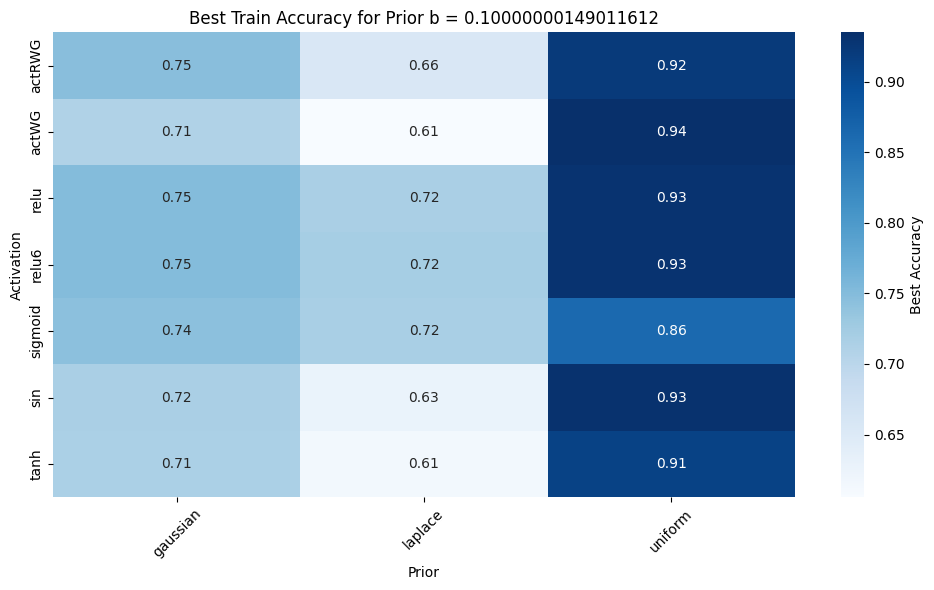

In [14]:
plot_prior_b_histogram(best_acc_df, 0.10000000149011612)

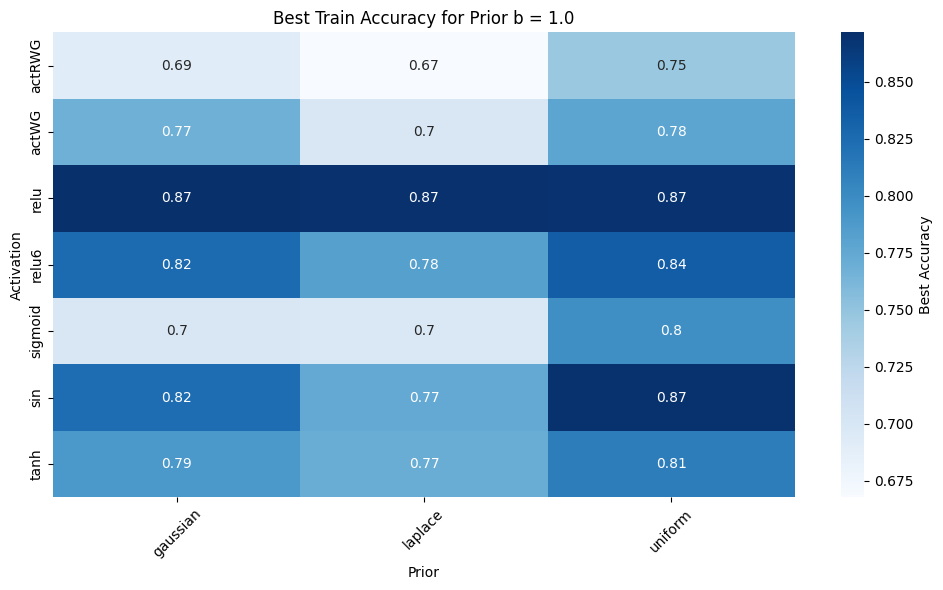

In [15]:
plot_prior_b_histogram(best_acc_df, 1.0)

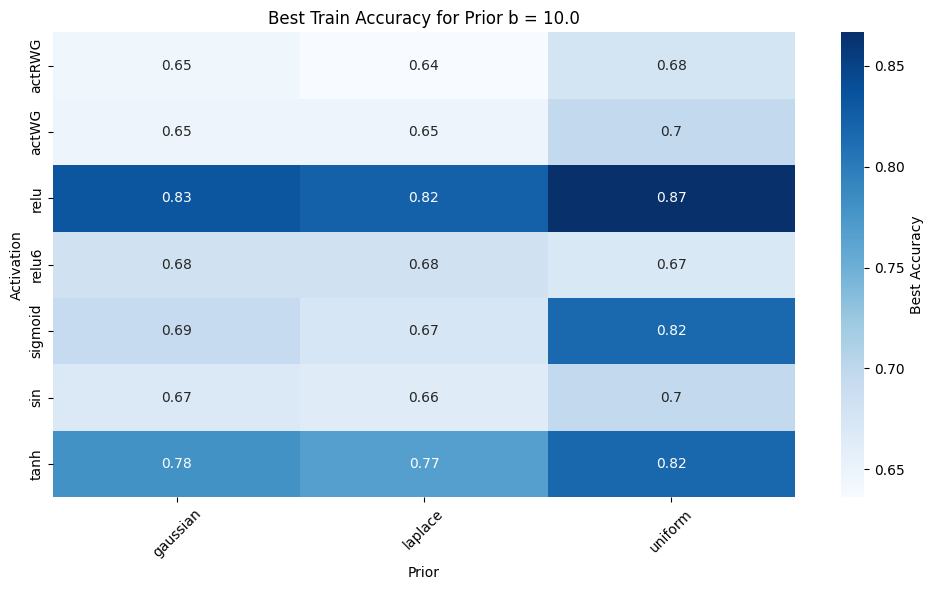

In [16]:
plot_prior_b_histogram(best_acc_df, 10.0)

From the results above, we can conclude that:
- uniform seemingly performs better in training across all b value (might be counterintuitive compared to what we believe in)

## Test Accuracy Analysis

In [17]:
# grab the csv files from the shipsnet_newslate_seu_result directory for 
prediction_files = {}

for timestamp in timestamps:
    prediction_files[timestamp] = [f for f in all_files if timestamp in f and f.endswith('.csv') and f.startswith('predictions')][0]

In [18]:
from sklearn.metrics import accuracy_score

In [19]:
best_test_acc_df = pd.DataFrame(columns=['timestamp', 'activation', 'prior', 'best_test_acc', 'prior_mu', 'prior_b'])

for ts in timestamps:
    model_config = load_model_config(ts)

    # Load the predictions
    pred_path = os.path.join('results_shipsnet_new_uniform','results_shipsnet_v02_01', prediction_files[ts])
    predictions = pd.read_csv(pred_path)

    # Calculate the accuracy
    y_true = predictions['True Label']
    y_pred = predictions['Predicted Label']
    best_test_acc = accuracy_score(y_true, y_pred)

    # Append to the DataFrame
    best_test_acc_df = pd.concat([best_test_acc_df, pd.DataFrame({
        'timestamp': [ts],
        'activation': [model_config['activation']],
        'prior': [model_config['prior']],
        'best_test_acc': [best_test_acc],
        'prior_mu': [model_config['prior_params']['mu']],
        'prior_b': [model_config['prior_params']['b']]
    })], ignore_index=True)

C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_6920\1676509453.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  best_test_acc_df = pd.concat([best_test_acc_df, pd.DataFrame({


In [20]:
best_test_acc_df

,timestamp,activation,prior,best_test_acc,prior_mu,prior_b
0,_20250806_090014,actRWG,gaussian,0.72625,0.0,10.0
1,_20250806_092151,actRWG,gaussian,0.75625,0.0,1.0
2,_20250806_094253,actRWG,gaussian,0.75000,0.0,0.1
3,_20250806_085758,actRWG,laplace,0.75625,0.0,10.0
4,_20250806_091924,actRWG,laplace,0.75750,0.0,1.0
...,...,...,...,...,...,...
58,_20250806_030724,tanh,laplace,0.87500,0.0,1.0
59,_20250806_033559,tanh,laplace,0.71500,0.0,0.1
60,_20250806_020144,tanh,uniform,0.90625,0.0,10.0
61,_20250806_022604,tanh,uniform,0.86625,0.0,1.0


In [21]:
#join the two dataframes on timestamp, activation, prior, prior_mu, and prior_b
merged_df = pd.merge(best_acc_df, best_test_acc_df, on=['timestamp', 'activation', 'prior', 'prior_mu', 'prior_b'], suffixes=('_train', '_test'))
merged_df["best_acc_diff"] = merged_df["best_acc"] - merged_df["best_test_acc"]
merged_df

,timestamp,activation,prior,best_acc,prior_mu,prior_b,best_test_acc,best_acc_diff
0,_20250806_090014,actRWG,gaussian,0.645312,0.0,10.0,0.72625,-0.080937
1,_20250806_092151,actRWG,gaussian,0.690937,0.0,1.0,0.75625,-0.065312
2,_20250806_094253,actRWG,gaussian,0.746875,0.0,0.1,0.75000,-0.003125
3,_20250806_085758,actRWG,laplace,0.636250,0.0,10.0,0.75625,-0.120000
4,_20250806_091924,actRWG,laplace,0.667813,0.0,1.0,0.75750,-0.089687
...,...,...,...,...,...,...,...,...
58,_20250806_030724,tanh,laplace,0.770625,0.0,1.0,0.87500,-0.104375
59,_20250806_033559,tanh,laplace,0.614062,0.0,0.1,0.71500,-0.100938
60,_20250806_020144,tanh,uniform,0.817813,0.0,10.0,0.90625,-0.088437
61,_20250806_022604,tanh,uniform,0.811562,0.0,1.0,0.86625,-0.054688


In [22]:
def plot_prior_b_histogram_test(df, prior_b_value):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Filter the DataFrame for the specific prior_b value
    filtered_df = df[df['prior_b'] == prior_b_value]

    # Create a pivot table for plotting
    pivot_df = filtered_df.pivot_table(index='activation', columns='prior', values='best_test_acc', aggfunc='mean')

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_df, annot=True, cmap='Blues', cbar_kws={'label': 'Best Accuracy'})
    plt.title(f'Test Accuracy for Prior b = {prior_b_value}')
    plt.xlabel('Prior')
    plt.ylabel('Activation')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

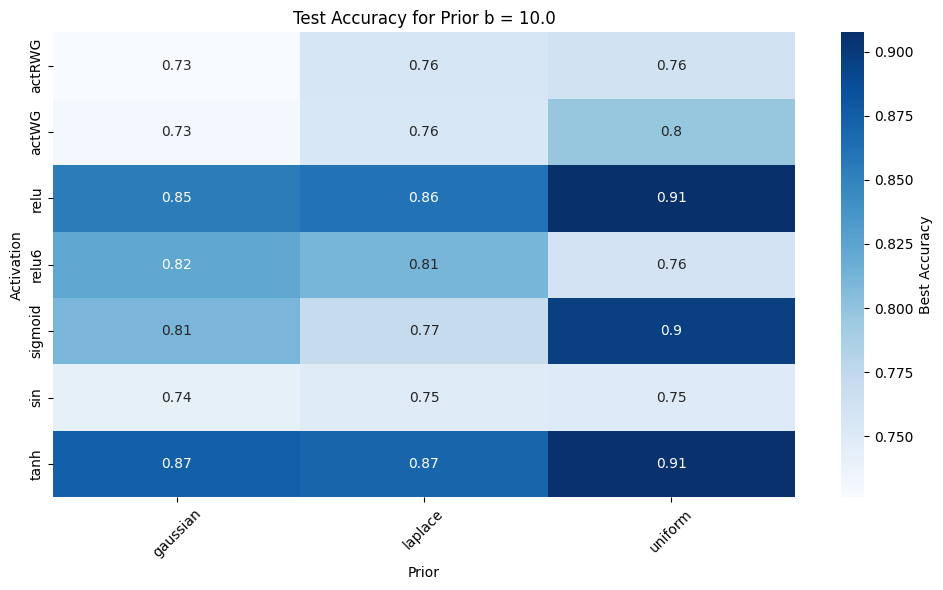

In [23]:
plot_prior_b_histogram_test(merged_df, 10.0)

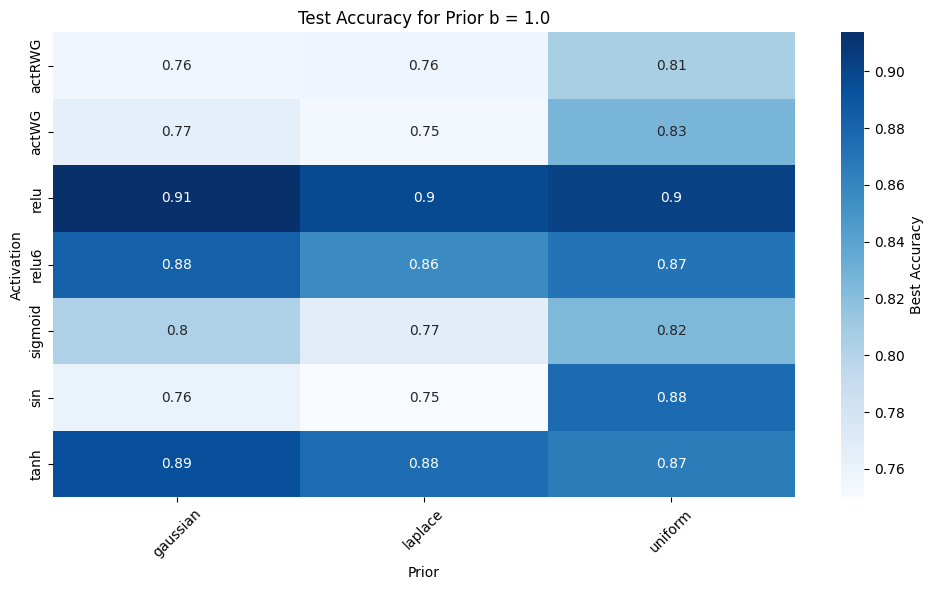

In [24]:
plot_prior_b_histogram_test(merged_df, 1.0)

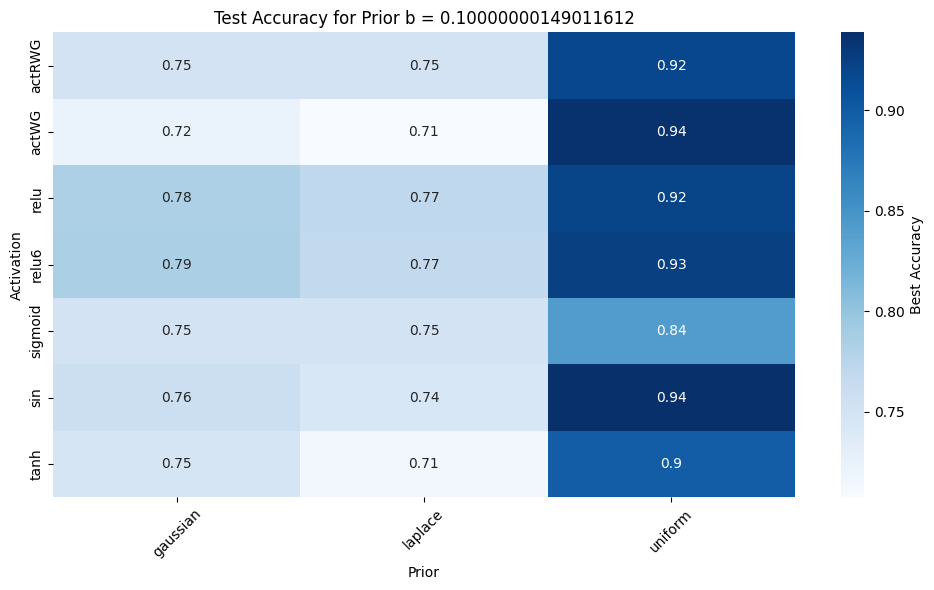

In [25]:
plot_prior_b_histogram_test(merged_df, 0.10000000149011612)

From the plots above, we can conclude that:
- uniform consistently better in test accuracy

## Train - Test Accuracy Difference Analysis

In [26]:
# same as above, but plot for the difference between best_acc and best_test_acc
# give a color scale of red if it went to minus, blue if it went to plus
import matplotlib.pyplot as plt
import seaborn as sns


def plot_prior_b_histogram_diff(df, prior_b_value):
    # Filter the DataFrame for the specific prior_b value
    filtered_df = df[df['prior_b'] == prior_b_value]

    # Create a pivot table for plotting
    pivot_df = filtered_df.pivot_table(index='activation', columns='prior', values='best_acc_diff', aggfunc='mean')

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_df, annot=True, cmap='coolwarm', center=0, cbar_kws={'label': 'Best Accuracy Difference'})
    plt.title(f'Best Accuracy Difference for Prior b = {prior_b_value}\nTrain - Test')
    plt.xlabel('Prior')
    plt.ylabel('Activation')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

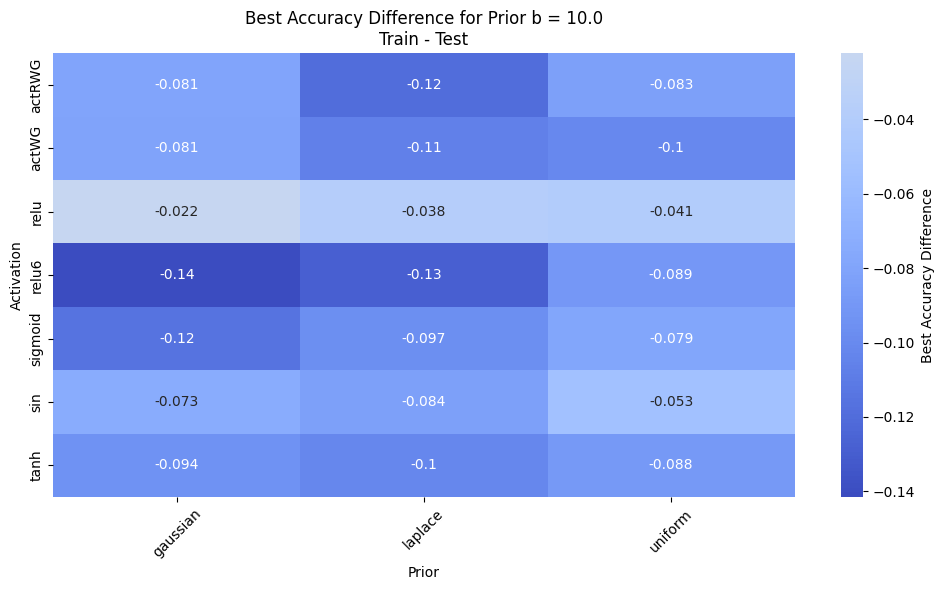

In [27]:
plot_prior_b_histogram_diff(merged_df, 10.0)

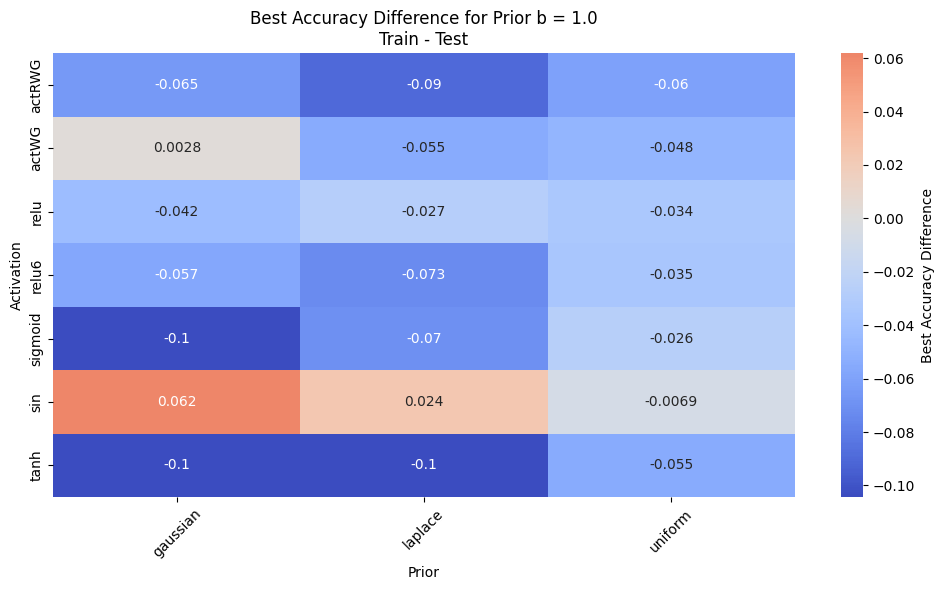

In [28]:
plot_prior_b_histogram_diff(merged_df, 1.0)

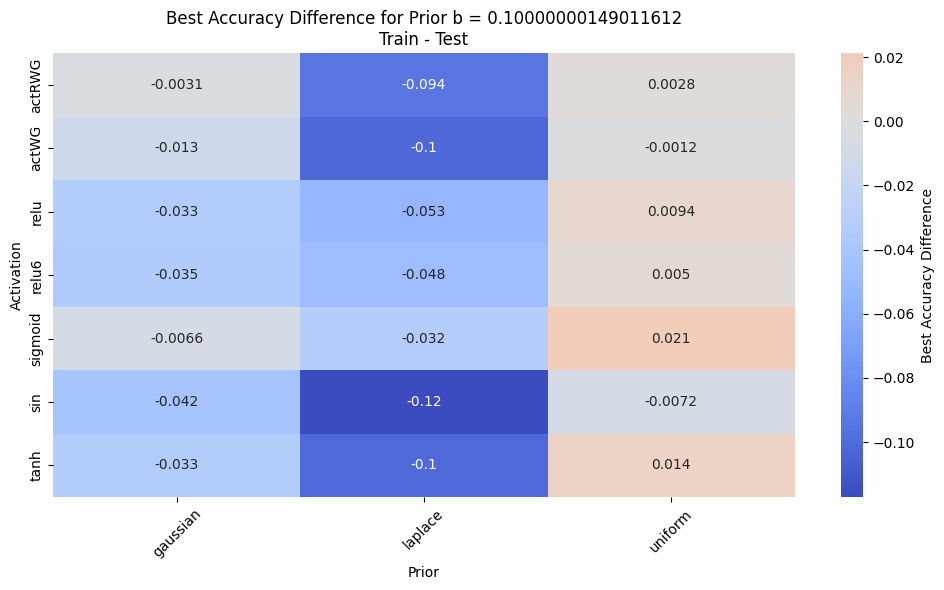

In [29]:
plot_prior_b_histogram_diff(merged_df, 0.10000000149011612)

In [30]:
# for uniform 0.1, get the confusion matrix

from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [31]:
merged_df

,timestamp,activation,prior,best_acc,prior_mu,prior_b,best_test_acc,best_acc_diff
0,_20250806_090014,actRWG,gaussian,0.645312,0.0,10.0,0.72625,-0.080937
1,_20250806_092151,actRWG,gaussian,0.690937,0.0,1.0,0.75625,-0.065312
2,_20250806_094253,actRWG,gaussian,0.746875,0.0,0.1,0.75000,-0.003125
3,_20250806_085758,actRWG,laplace,0.636250,0.0,10.0,0.75625,-0.120000
4,_20250806_091924,actRWG,laplace,0.667813,0.0,1.0,0.75750,-0.089687
...,...,...,...,...,...,...,...,...
58,_20250806_030724,tanh,laplace,0.770625,0.0,1.0,0.87500,-0.104375
59,_20250806_033559,tanh,laplace,0.614062,0.0,0.1,0.71500,-0.100938
60,_20250806_020144,tanh,uniform,0.817813,0.0,10.0,0.90625,-0.088437
61,_20250806_022604,tanh,uniform,0.811562,0.0,1.0,0.86625,-0.054688


In [32]:
#predictions = pd.read_csv(os.path.join('results_GP_shipsnet_newslate', prediction_files[timestamps[2]]))

#get the predictions object by filtering the timestamp from merged_df based on prior_b and activation
def show_cf_matrix(prior_b, prior, activation):

    target_timestmap = merged_df[
        (merged_df['prior_b'] == prior_b) & 
        (merged_df['prior'] == prior) &
        (merged_df['activation'] == activation)
    ].iloc[0, 0]

    predictions = pd.read_csv(os.path.join('results_shipsnet_new_uniform','results_shipsnet_v02_01', prediction_files[target_timestmap]))

    plot_confusion_matrix(y_true=predictions['True Label'], 
                        y_pred=predictions['Predicted Label'], 
                        title=f'Confusion Matrix for {activation} {prior} {prior_b:.2f} Prior')

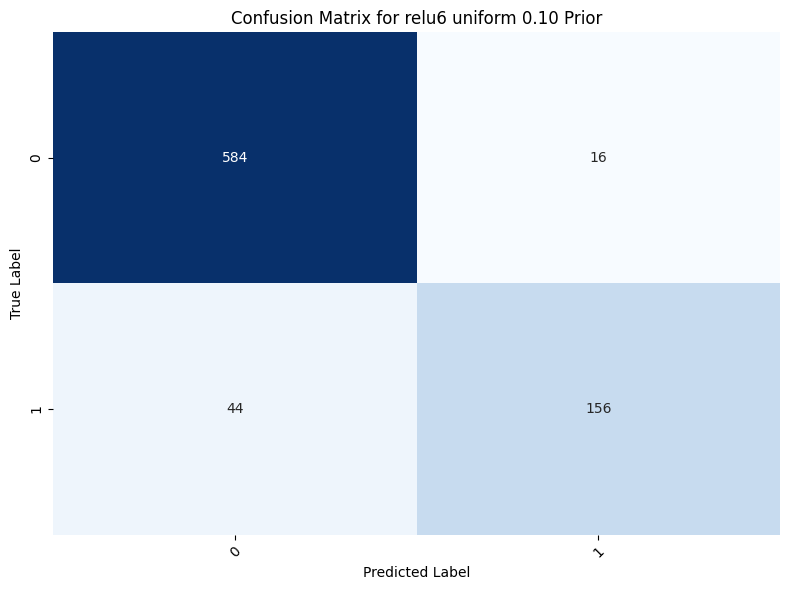

In [33]:
show_cf_matrix(0.10000000149011612, 'uniform', 'relu6')

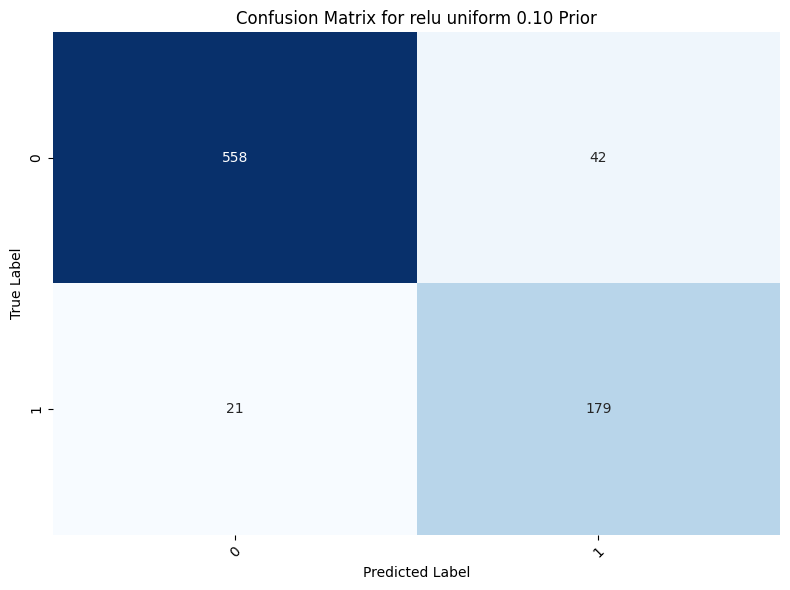

In [34]:
show_cf_matrix(0.10000000149011612, 'uniform', 'relu')

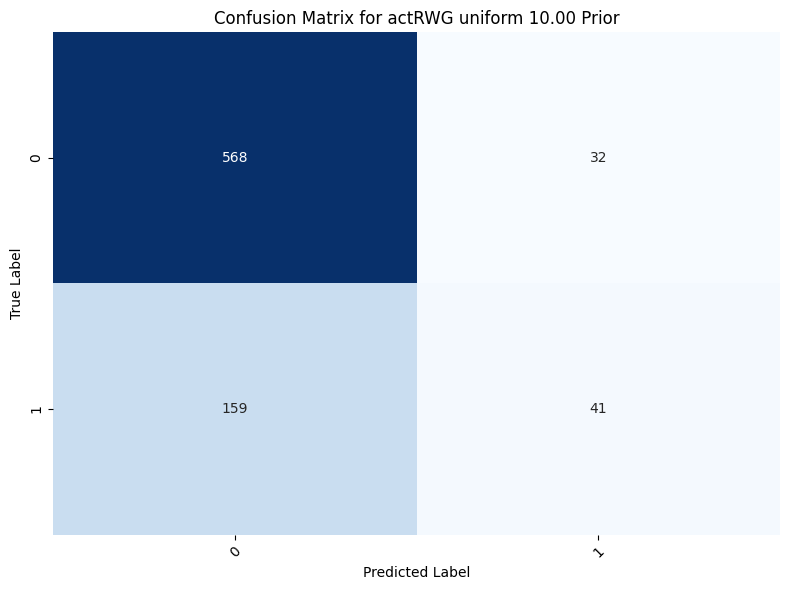

In [35]:
show_cf_matrix(10.0, 'uniform', 'actRWG')

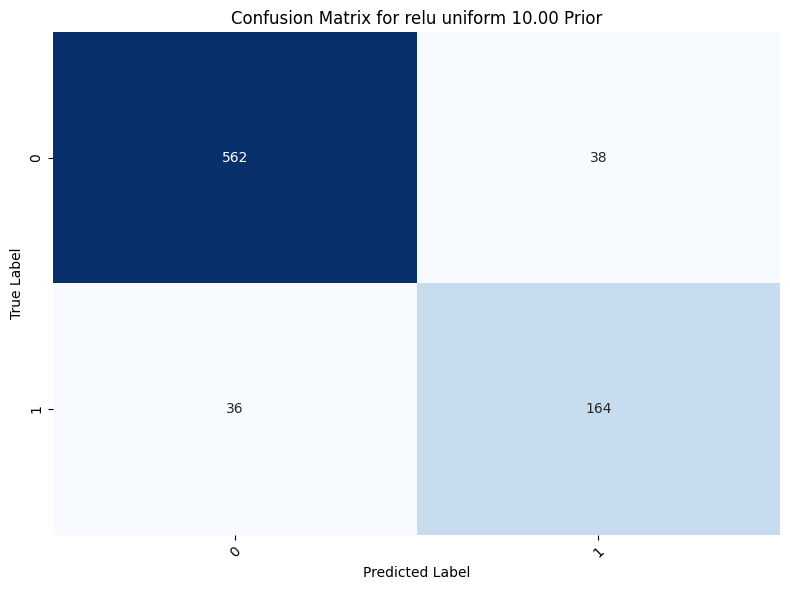

In [36]:
# best test accuracy
show_cf_matrix(10.0, 'uniform', 'relu')

From the confusion matrix, we can see that those with 0.75 accuracy tend to predic for class 0

# Weight and Bias Parameter Distribution

In [37]:
param_files

{'_20250806_090014': 'param_store_actRWG_gaussian_epoch_best_20250806_090014.pkl',
 '_20250806_092151': 'param_store_actRWG_gaussian_epoch_best_20250806_092151.pkl',
 '_20250806_094253': 'param_store_actRWG_gaussian_epoch_best_20250806_094253.pkl',
 '_20250806_085758': 'param_store_actRWG_laplace_epoch_best_20250806_085758.pkl',
 '_20250806_091924': 'param_store_actRWG_laplace_epoch_best_20250806_091924.pkl',
 '_20250806_094016': 'param_store_actRWG_laplace_epoch_best_20250806_094016.pkl',
 '_20250806_055733': 'param_store_actRWG_uniform_epoch_best_20250806_055733.pkl',
 '_20250806_061750': 'param_store_actRWG_uniform_epoch_best_20250806_061750.pkl',
 '_20250806_062951': 'param_store_actRWG_uniform_epoch_best_20250806_062951.pkl',
 '_20250806_075655': 'param_store_actWG_gaussian_epoch_best_20250806_075655.pkl',
 '_20250806_081811': 'param_store_actWG_gaussian_epoch_best_20250806_081811.pkl',
 '_20250806_083918': 'param_store_actWG_gaussian_epoch_best_20250806_083918.pkl',
 '_20250806_0

In [38]:
import pyro
import torch

c:\Users\Revalda Putawara\.conda\envs\bnntest\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [39]:
timestamp_target = '_20250806_013752'

merged_df[merged_df['timestamp'] == timestamp_target]

#store the value of the prior, prior_mu, and prior_b
target_prior = merged_df[merged_df['timestamp'] == timestamp_target]['prior'].values[0]
target_prior_mu = merged_df[merged_df['timestamp'] == timestamp_target]['prior_mu'].values[0]
target_prior_b = merged_df[merged_df['timestamp'] == timestamp_target]['prior_b'].values[0]
target_activation = merged_df[merged_df['timestamp'] == timestamp_target]['activation'].values[0]

pyro.clear_param_store()
pyro.get_param_store().set_state(torch.load(os.path.join('results_shipsnet_new_uniform','results_shipsnet_v02_01',param_files[timestamp_target]), weights_only=False))

pyro_parameter_values = {}

for name, value in pyro.get_param_store().items():
    pyro_parameter_values[name.replace("AutoUniform.","")] = value.cpu().detach().numpy()

In [40]:
pyro_parameter_values

{'lows.conv1.weight': array([[[[-0.28093082, -0.2711268 , -0.2876285 ],
          [-0.28276998, -0.25095552, -0.26869607],
          [-0.299894  , -0.24700662, -0.2690485 ]],
 
         [[-0.37234485, -0.3524944 , -0.36247754],
          [-0.34745118, -0.29375046, -0.31929415],
          [-0.3766297 , -0.3156628 , -0.30523527]],
 
         [[-0.37024927, -0.33854514, -0.34447944],
          [-0.3430624 , -0.28970945, -0.286196  ],
          [-0.36766618, -0.3051456 , -0.29996726]]],
 
 
        [[[-0.21011609, -0.16780487, -0.18221307],
          [-0.2004985 , -0.18090868, -0.17970274],
          [-0.25290138, -0.2445835 , -0.21833119]],
 
         [[-0.3574154 , -0.30110103, -0.30334786],
          [-0.33407506, -0.31449798, -0.2893518 ],
          [-0.38781622, -0.36676544, -0.33527598]],
 
         [[-0.41301346, -0.35105014, -0.3478556 ],
          [-0.39589188, -0.36763865, -0.33384886],
          [-0.4493464 , -0.4128415 , -0.378767  ]]],
 
 
        [[[-0.20198174, -0.17585558, 

## Drawing Samples from the Guide

In [41]:
model_config

{'activation': 'tanh',
 'prior': 'uniform',
 'num_epochs': 100,
 'best_accuracy_at_epoch': 1,
 'best_accuracy': 0.913125,
 'batch_size': 16,
 'train_size': 3200,
 'prior_params': {'mu': 0.0, 'b': 0.10000000149011612}}

In [42]:
# import autonormal guide
from pyro.infer.autoguide import AutoNormal

In [43]:
import torch

In [44]:
from pyro.nn.module import PyroModule, PyroParam
from pyro.infer.autoguide import AutoGuide
from pyro.infer.autoguide.initialization import InitMessenger, init_to_feasible
from pyro.distributions import constraints
from contextlib import ExitStack

from pyro.distributions.util       import sum_rightmost
from pyro.ops.tensor_utils         import periodic_repeat
from pyro.distributions.transforms import biject_to
from pyro.infer.autoguide.utils    import (
    deep_setattr,
    deep_getattr,
    helpful_support_errors,
)

import pyro.poutine as poutine


class AutoLaplace(AutoGuide):
    """
    An AutoGuide that uses a Laplace(loc, scale) marginal for each latent.
    """
    scale_constraint = constraints.softplus_positive

    def __init__(
        self, model, *, init_loc_fn=init_to_feasible, init_scale=0.1, create_plates=None
    ):
        self.init_loc_fn = init_loc_fn
        if not isinstance(init_scale, float) or not (init_scale > 0):
            raise ValueError(f"Expected init_scale > 0, got {init_scale}")
        self._init_scale = init_scale

        model = InitMessenger(self.init_loc_fn)(model)
        super().__init__(model, create_plates=create_plates)

    def _setup_prototype(self, *args, **kwargs):
        super()._setup_prototype(*args, **kwargs)

        self._event_dims = {}
        self.locs = PyroModule()
        self.scales = PyroModule()

        for name, site in self.prototype_trace.iter_stochastic_nodes():
            # ← use helpful_support_errors directly
            with helpful_support_errors(site):
                init_loc = (
                    biject_to(site["fn"].support)
                    .inv(site["value"].detach())
                    .detach()
                )
            event_dim = site["fn"].event_dim + init_loc.dim() - site["value"].dim()
            self._event_dims[name] = event_dim

            # handle subsampling plates
            for frame in site["cond_indep_stack"]:
                full_size = frame.full_size or frame.size
                if full_size != frame.size:
                    dim = frame.dim - event_dim
                    init_loc = periodic_repeat(init_loc, full_size, dim).contiguous()

            init_scale = torch.full_like(init_loc, self._init_scale)

            deep_setattr(
                self.locs, name, PyroParam(init_loc, constraints.real, event_dim)
            )
            deep_setattr(
                self.scales,
                name,
                PyroParam(init_scale, self.scale_constraint, event_dim),
            )

    def _get_loc_and_scale(self, name):
        site_loc = deep_getattr(self.locs, name)
        site_scale = deep_getattr(self.scales, name)
        return site_loc, site_scale

    def forward(self, *args, **kwargs):
        if self.prototype_trace is None:
            self._setup_prototype(*args, **kwargs)

        plates = self._create_plates(*args, **kwargs)
        result = {}

        for name, site in self.prototype_trace.iter_stochastic_nodes():
            transform = biject_to(site["fn"].support)

            with ExitStack() as stack:
                for frame in site["cond_indep_stack"]:
                    if frame.vectorized:
                        stack.enter_context(plates[frame.name])

                site_loc, site_scale = self._get_loc_and_scale(name)

                unconstrained = pyro.sample(
                    f"{name}_unconstrained",
                    dist.Laplace(site_loc, site_scale)
                        .to_event(self._event_dims[name]),
                    infer={"is_auxiliary": True},
                )

                value = transform(unconstrained)
                if poutine.get_mask() is False:
                    log_density = 0.0
                else:
                    log_density = transform.inv.log_abs_det_jacobian(
                        value, unconstrained
                    )
                    log_density = sum_rightmost(
                        log_density,
                        log_density.dim() - value.dim() + site["fn"].event_dim,
                    )
                delta = dist.Delta(
                    value,
                    log_density=log_density,
                    event_dim=site["fn"].event_dim,
                )
                result[name] = pyro.sample(name, delta)

        return result

    @torch.no_grad()
    def median(self, *args, **kwargs):
        medians = {}
        for name, site in self.prototype_trace.iter_stochastic_nodes():
            site_loc, _ = self._get_loc_and_scale(name)
            med = biject_to(site["fn"].support)(site_loc)
            medians[name] = med.clone() if med is site_loc else med
        return medians

    @torch.no_grad()
    def quantiles(self, quantiles, *args, **kwargs):
        results = {}
        for name, site in self.prototype_trace.iter_stochastic_nodes():
            site_loc, site_scale = self._get_loc_and_scale(name)
            qs = torch.tensor(quantiles, dtype=site_loc.dtype, device=site_loc.device)
            qs = qs.reshape((-1,) + (1,) * site_loc.dim())
            qvals = dist.Laplace(site_loc, site_scale).icdf(qs)
            results[name] = biject_to(site["fn"].support)(qvals)
        return results


class AutoUniform(AutoGuide):
    """
    An AutoGuide that uses a Uniform(low, low+width) marginal for each latent.
    """
    # `width` must be positive
    width_constraint = constraints.softplus_positive

    def __init__(
        self, model, *, init_loc_fn=init_to_feasible, init_scale=0.1, create_plates=None
    ):
        self.init_loc_fn = init_loc_fn
        if not isinstance(init_scale, float) or not (init_scale > 0):
            raise ValueError(f"Expected init_scale > 0, got {init_scale}")
        self._init_scale = init_scale

        model = InitMessenger(self.init_loc_fn)(model)
        super().__init__(model, create_plates=create_plates)

    def _setup_prototype(self, *args, **kwargs):
        super()._setup_prototype(*args, **kwargs)
        self._event_dims = {}
        self.lows = PyroModule()
        self.widths = PyroModule()

        for name, site in self.prototype_trace.iter_stochastic_nodes():
            # 1. get an unconstrained init_loc (inverse‐transform of site["value"])
            with helpful_support_errors(site):
                init_loc = (
                    biject_to(site["fn"].support)
                    .inv(site["value"].detach())
                    .detach()
                )
            event_dim = site["fn"].event_dim + init_loc.dim() - site["value"].dim()
            self._event_dims[name] = event_dim

            # 2. if subsampled, expand back to full size
            for frame in site["cond_indep_stack"]:
                full_size = frame.full_size or frame.size
                if full_size != frame.size:
                    dim = frame.dim - event_dim
                    init_loc = periodic_repeat(init_loc, full_size, dim).contiguous()

            # 3. build initial low & width around that init_loc
            init_low   = init_loc - self._init_scale
            init_width = torch.full_like(init_loc, 2.0 * self._init_scale)

            # 4. register as PyroParams
            deep_setattr(
                self.lows,  name,
                PyroParam(init_low,   constraints.real,             event_dim),
            )
            deep_setattr(
                self.widths, name,
                PyroParam(init_width, self.width_constraint,       event_dim),
            )

    def _get_low_and_width(self, name):
        low   = deep_getattr(self.lows,  name)
        width = deep_getattr(self.widths, name)
        return low, width

    def forward(self, *args, **kwargs):
        if self.prototype_trace is None:
            self._setup_prototype(*args, **kwargs)

        plates = self._create_plates(*args, **kwargs)
        result = {}

        for name, site in self.prototype_trace.iter_stochastic_nodes():
            transform = biject_to(site["fn"].support)
            with ExitStack() as stack:
                for frame in site["cond_indep_stack"]:
                    if frame.vectorized:
                        stack.enter_context(plates[frame.name])

                low, width = self._get_low_and_width(name)
                # draw unconstrained latent from Uniform(low, low + width)
                unconstrained = pyro.sample(
                    f"{name}_unconstrained",
                    dist.Uniform(low, low + width).to_event(self._event_dims[name]),
                    infer={"is_auxiliary": True},
                )

                # map into constrained space
                value = transform(unconstrained)
                if poutine.get_mask() is False:
                    log_density = 0.0
                else:
                    log_density = transform.inv.log_abs_det_jacobian(
                        value, unconstrained
                    )
                    log_density = sum_rightmost(
                        log_density,
                        log_density.dim() - value.dim() + site["fn"].event_dim,
                    )
                delta = dist.Delta(
                    value,
                    log_density=log_density,
                    event_dim=site["fn"].event_dim,
                )
                result[name] = pyro.sample(name, delta)

        return result

    @torch.no_grad()
    def median(self, *args, **kwargs):
        """
        Posterior median is just the 0.5‐quantile of Uniform = low + 0.5*width
        """
        medians = {}
        for name, site in self.prototype_trace.iter_stochastic_nodes():
            low, width = self._get_low_and_width(name)
            med = biject_to(site["fn"].support)(low + 0.5 * width)
            medians[name] = med.clone() if med is low else med
        return medians

    @torch.no_grad()
    def quantiles(self, quantiles, *args, **kwargs):
        """
        Posterior quantiles via Uniform.icdf(q).
        """
        results = {}
        qs = torch.tensor(quantiles)
        for name, site in self.prototype_trace.iter_stochastic_nodes():
            low, width = self._get_low_and_width(name)
            # shape: [len(quantiles), *low.shape]
            qvals = dist.Uniform(low, low + width).icdf(qs.reshape((-1,) + (1,) * low.dim()))
            results[name] = biject_to(site["fn"].support)(qvals)
        return results

In [45]:
from pyro.nn import PyroModule, PyroSample

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample

In [47]:
# Added
class UniformReal(dist.Uniform):
    @property
    def support(self):
        return constraints.real

class BayesShipsCNNSmartpool(PyroModule):
    def __init__(
        self,
        num_classes=2,   # now 2 for Categorical
        device=torch.device("cuda"),
        activation='relu',
        prior_dist='gaussian',
        mu=0.0,
        b=1.0,
        prior_params=None,
        smartpool_switch = False,
        pool_threshold=10.0,
        pool_detect_only=False,
        dropout_switch=False,
        dropout_p=0.5
    ):
        super().__init__()
        self.device = device

        # Activation setup
        if isinstance(activation, str):
            act_map = {
                'relu': F.relu,
                'tanh': torch.tanh,
                'sigmoid': torch.sigmoid,
                'sinusoidal': torch.sin,
                'relu6': F.relu6,
                'leaky_relu': F.leaky_relu,
                'selu': F.selu,
                'wg': self.actWG,
                'rwg': self.actRWG,
            }
            self.activation_fn = act_map[activation]
        elif callable(activation):
            self.activation_fn = activation
        else:
            raise ValueError("activation must be a string or callable")

        # Prior setup
        self.prior_dist = prior_dist
        params = {'mu': mu, 'b': b} if prior_params is None else prior_params
        self.prior_mu = torch.tensor(params['mu'], device=device, dtype=torch.float32)
        self.prior_b  = torch.tensor(params['b'], device=device, dtype=torch.float32)

        print(f"[INFO] Using prior: {self.prior_dist} (mu={self.prior_mu.item()}, b={self.prior_b.item()})")

        # Layers
        self.conv1 = PyroModule[nn.Conv2d](3, 32, kernel_size=3, padding=1)
        self.conv1.weight = PyroSample(self._make_prior([32, 3, 3, 3]))
        self.conv1.bias   = PyroSample(self._make_prior([32]))

        self.conv2 = PyroModule[nn.Conv2d](32, 64, kernel_size=3, padding=1)
        self.conv2.weight = PyroSample(self._make_prior([64, 32, 3, 3]))
        self.conv2.bias   = PyroSample(self._make_prior([64]))

        if not smartpool_switch:
            self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        elif smartpool_switch:

            self.pool = SmartPool(
                kernel_size=2,
                stride=2,
                threshold=pool_threshold,
                detect_only=pool_detect_only
            )

        self.dropout_switch = dropout_switch

        if self.dropout_switch:
            self.dropout = nn.Dropout(p=dropout_p)

        self.fc1 = PyroModule[nn.Linear](64 * 16 * 16, num_classes)
        self.fc1.weight = PyroSample(self._make_prior([num_classes, 64 * 16 * 16]))
        self.fc1.bias   = PyroSample(self._make_prior([num_classes]))

    def actWG(self, x, alpha=1.0):
        return x * torch.exp(-alpha * x ** 2)

    def actRWG(self, x, alpha=1.0):
        wg = x * torch.exp(-alpha * x ** 2)
        return torch.max(torch.zeros_like(wg), wg)

    def _make_prior(self, shape):
        if self.prior_dist == 'gaussian':
            base = dist.Normal(self.prior_mu, self.prior_b)
        elif self.prior_dist == 'laplace':
            base = dist.Laplace(self.prior_mu, self.prior_b)
        elif self.prior_dist == 'uniform':
            #base = dist.Uniform(-self.prior_b, self.prior_b)
            base = UniformReal(-self.prior_b, self.prior_b)
        else:
            raise ValueError(f"Unsupported prior: {self.prior_dist}")
        return base.expand(shape).to_event(len(shape))

    def forward(self, x, y=None):
        x = self.activation_fn(self.conv1(x))
        x = self.pool(x)
        x = self.activation_fn(self.conv2(x))
        x = self.pool(x)

        #if self.dropout_switch:
        #    x = self.dropout(x)

        if self.dropout_switch and self.training: #ADDED ON AUGUST 02
            x = self.dropout(x)

        x = x.view(x.size(0), -1)
        logits = self.fc1(x)  # shape [batch, 2]

        if y is not None:
            with pyro.plate("data", x.size(0)):
                pyro.sample("obs", dist.Categorical(logits=logits), obs=y)
        return logits

In [ ]:
#config_files = {}
#guide_files = {}
#model_files = {}
#param_files = {}

In [48]:
# loop thriugh timestamps and check the model config
for ts_idx, timestamp in enumerate(timestamps):
    model_config = load_model_config(timestamp)

    # Check if the model config matches the expected structure
    if model_config['activation'] == 'relu' and model_config['prior'] == 'uniform' and model_config['prior_params']['b'] == 1.0:
        print(f"Timestamp: {timestamp}, Activation: {model_config['activation']}, Prior: {model_config['prior']}")
        print(f"Prior Params: mu={model_config['prior_params']['mu']}, b={model_config['prior_params']['b']}")
        print("Model Config:", model_config)
        print("-" * 50)
        print("ts_idx:", ts_idx)
        ts_idx_set = ts_idx

Timestamp: _20250806_013752, Activation: relu, Prior: uniform
Prior Params: mu=0.0, b=1.0
Model Config: {'activation': 'relu', 'prior': 'uniform', 'num_epochs': 100, 'best_accuracy_at_epoch': 50, 'best_accuracy': 0.8684375, 'batch_size': 16, 'train_size': 3200, 'prior_params': {'mu': 0.0, 'b': 1.0}}
--------------------------------------------------
ts_idx: 34


In [49]:
# 34 relu uniform 1.0

#ts_idx = 34

model_config = load_model_config(timestamps[ts_idx_set])
#model_config = load_model_config('_20250718_232229')
#model_config = load_model_config('_20250718_232106')

model_config

{'activation': 'relu',
 'prior': 'uniform',
 'num_epochs': 100,
 'best_accuracy_at_epoch': 50,
 'best_accuracy': 0.8684375,
 'batch_size': 16,
 'train_size': 3200,
 'prior_params': {'mu': 0.0, 'b': 1.0}}

In [50]:
from pyro.infer import Predictive

import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

from torchvision.datasets import ImageFolder
import pickle

from torch.utils.data import Subset

In [51]:
shipsnet_mean = [0.4119, 0.4243, 0.3724]
shipsnet_std = [0.1899, 0.1569, 0.1515]

In [52]:
def load_data(batch_size=16):
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=shipsnet_mean, 
                             std=shipsnet_std)
    ])

    #dataset = datasets.EuroSAT(root='./data', transform=transform, download=True)
    dataset = ImageFolder(
    root="data/shipsnet/foldered",
    transform=transform
    )
    torch.manual_seed(42)

    #train_size = int(0.8 * len(dataset))
    #test_size = len(dataset) - train_size
    #train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
    
    with open('datasplit/shipsnet_split_indices.pkl', 'rb') as f:
        split = pickle.load(f)
        train_dataset = Subset(dataset, split['train'])
        test_dataset = Subset(dataset, split['test'])

    # Add num_workers and pin_memory for faster data loading
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                             num_workers=4, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size,
                            num_workers=4, pin_memory=True, persistent_workers=True)
    return train_loader, test_loader

In [53]:
#plot the distribution of the samples in a histogram
#print the y values in its absolute value
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def plot_weight_distribution(samples,
                             layer_name,
                             module_name,
                             activation,
                             prior,
                             mu,
                             b):
    plt.figure(figsize=(10, 6))
    
    # Plot the histogram
    plt.hist(samples.cpu().numpy().flatten(), bins=50, density=True, alpha=0.6, color='g')
    
    # Title and axis labels
    plt.title("Weight Distribution for {}.{}\nAct : {}\nExpected distribution: {}({},{:.2f})".format(
        layer_name, 
        module_name,
        activation,
        prior,
        mu,
        b))
    
    plt.xlabel('Weight Value')
    plt.ylabel('Density')
    plt.grid(True)
    
    # Disable scientific notation on the x-axis
    ax = plt.gca()
    formatter = ScalarFormatter(useMathText=False)
    formatter.set_scientific(False)
    formatter.set_useOffset(False)
    ax.xaxis.set_major_formatter(formatter)

    plt.tight_layout()
    plt.show()


In [54]:
model_config

{'activation': 'relu',
 'prior': 'uniform',
 'num_epochs': 100,
 'best_accuracy_at_epoch': 50,
 'best_accuracy': 0.8684375,
 'batch_size': 16,
 'train_size': 3200,
 'prior_params': {'mu': 0.0, 'b': 1.0}}

In [55]:
#reset pyro param store
pyro.clear_param_store()
pyro.get_param_store().set_state(torch.load(os.path.join('results_shipsnet_new_uniform','results_shipsnet_v02_01',param_files[timestamps[ts_idx_set]]), weights_only=False))

In [57]:
def generate_predictive_result(timestamp,model_config, device, loader_of_interest, num_samples):
    model_config = load_model_config(timestamp)

    prior_of_interest = model_config['prior']

    if model_config['prior'] == 'sin':
        prior_of_interest = 'sinusoidal'

    #bayesian_model  = BayesShipsCNN(num_classes=2,
    #                            device=torch.device("cuda"),
    #                            activation=model_config['activation'],
    #                            prior_dist=prior_of_interest,
    #                            mu=model_config['prior_params']['mu'],
    #                            b=model_config['prior_params']['b'],
    #                            )
    
    bayesian_model = BayesShipsCNNSmartpool(num_classes=2,
        device=torch.device("cuda"),
        activation=model_config['activation'],
        prior_dist=prior_of_interest,
        mu =model_config['prior_params']['mu'],
        b=model_config['prior_params']['b'],
        )
    
    activation_iter = model_config['activation']
    prior_iter = model_config['prior']

    if prior_iter == 'gaussian':
        guide = AutoNormal(bayesian_model, init_scale=0.05).to(device)
    elif prior_iter == 'laplace':
        guide = AutoLaplace(bayesian_model, init_scale=0.05).to(device)
    elif prior_iter == 'uniform':
        guide = AutoUniform(bayesian_model, init_scale=0.05).to(device)

    #predictive = Predictive(bayesian_model,
    #                    guide=guide,
    #                    num_samples=num_samples)
    
    #x0, y0 = next(iter(loader_of_interest))
    #x0, y0 = x0.to(device), y0.to(device)
    
    #predictive_result = predictive(x0, y0)

    predictive_w = Predictive(
    bayesian_model,
    guide=guide,
    num_samples=500,
    return_sites=["conv1.weight"]
    )

    x0, _ = next(iter(loader_of_interest))
    x0 = x0.to(device)

    weight_samples = predictive_w(x0)
    W = weight_samples["conv1.weight"]

    first_neuron = W[:, 0]   # shape [500, in_channels, kH, kW]
    flat = first_neuron.flatten(start_dim=1)

    #return predictive_result
    return flat

In [58]:
predictive_result_target = generate_predictive_result(
    timestamps[ts_idx_set],
    #'_20250718_232229',
    #'_20250718_232106',
    model_config,
    device=torch.device("cuda"),
    loader_of_interest=next(iter(load_data(batch_size=16))),
    num_samples=500
)

[INFO] Using prior: uniform (mu=0.0, b=1.0)


In [59]:
layer_of_interest = "conv1"
module_of_interest = "weight"

samples = predictive_result_target

samples_first = samples[:, 0:1].flatten()

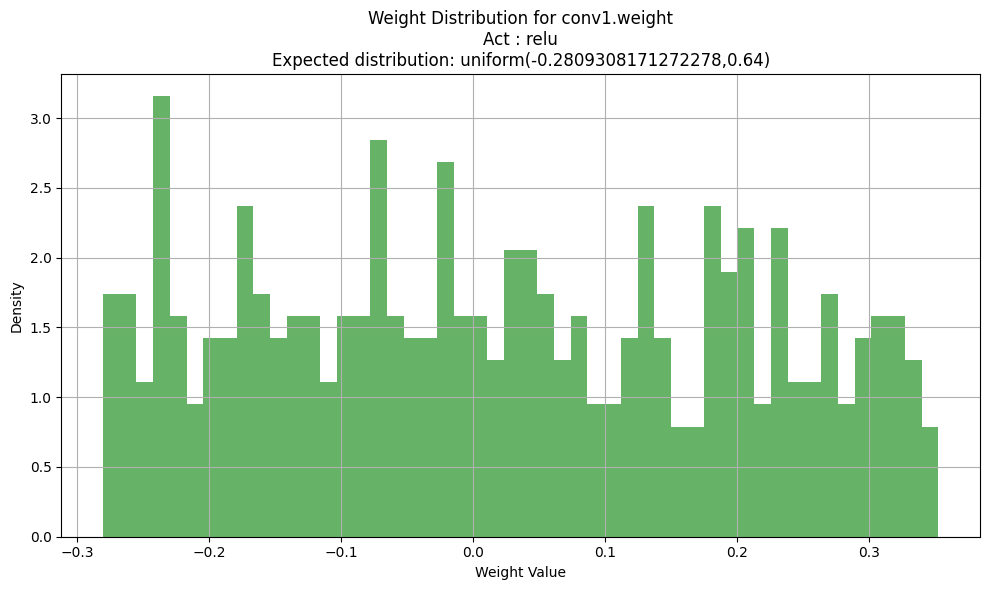

In [60]:
plot_weight_distribution(samples_first,
                        layer_of_interest,
                        module_of_interest,
                        model_config['activation'],
                        model_config['prior'],
                        pyro.get_param_store()['AutoUniform.lows.conv1.weight'][0][0][0][0].cpu().detach().numpy(),
                        pyro.get_param_store()['AutoUniform.widths.conv1.weight'][0][0][0][0].cpu().detach().numpy())

In [ ]:
plot_weight_distribution(samples,
                        layer_of_interest,
                        module_of_interest,
                        model_config['activation'],
                        model_config['prior'],
                        model_config['prior_params']['mu'],
                        model_config['prior_params']['b'])

In [ ]:
# print pyro param store values for the layer of interest
for name, value in pyro.get_param_store().items():
    if layer_of_interest in name and module_of_interest in name:
        print(f"{name}: {value.cpu().detach().numpy()[0][0][0][0]}")

In [ ]:
plot_weight_distribution(samples_first,
                        layer_of_interest,
                        module_of_interest,
                        model_config['activation'],
                        model_config['prior'],
                        pyro.get_param_store()['AutoUniform.lows.conv1.weight'][0][0][0][0].cpu().detach().numpy(),
                        pyro.get_param_store()['AutoUniform.widths.conv1.weight'][0][0][0][0].cpu().detach().numpy())

## SEU test

In [61]:
pyro.param("AutoUniform.lows.conv1.weight").data[0][0][0][0].fill_(1e3)

tensor(1000., device='cuda:0')

In [62]:
# print pyro param store values for the layer of interest
for name, value in pyro.get_param_store().items():
    if layer_of_interest in name and module_of_interest in name:
        print(f"{name}: {value.cpu().detach().numpy()[0][0][0][0]}")

AutoUniform.lows.conv1.weight: 1000.0
AutoUniform.widths.conv1.weight: 0.6353963613510132


In [63]:
pyro.get_param_store()['AutoUniform.lows.conv1.weight'][0][0][0][0].cpu().detach().numpy()

array(1000., dtype=float32)

In [64]:
predictive_result_target_new = generate_predictive_result(
    timestamps[ts_idx_set],
    #'_20250718_232229',
    #'_20250718_232106',
    model_config,
    device=torch.device("cuda"),
    loader_of_interest=next(iter(load_data(batch_size=16))),
    num_samples=500
)

[INFO] Using prior: uniform (mu=0.0, b=1.0)


In [65]:
layer_of_interest = "conv1"
module_of_interest = "weight"

samples_new = predictive_result_target_new

samples_new_first = samples_new[:, 0:1].flatten()

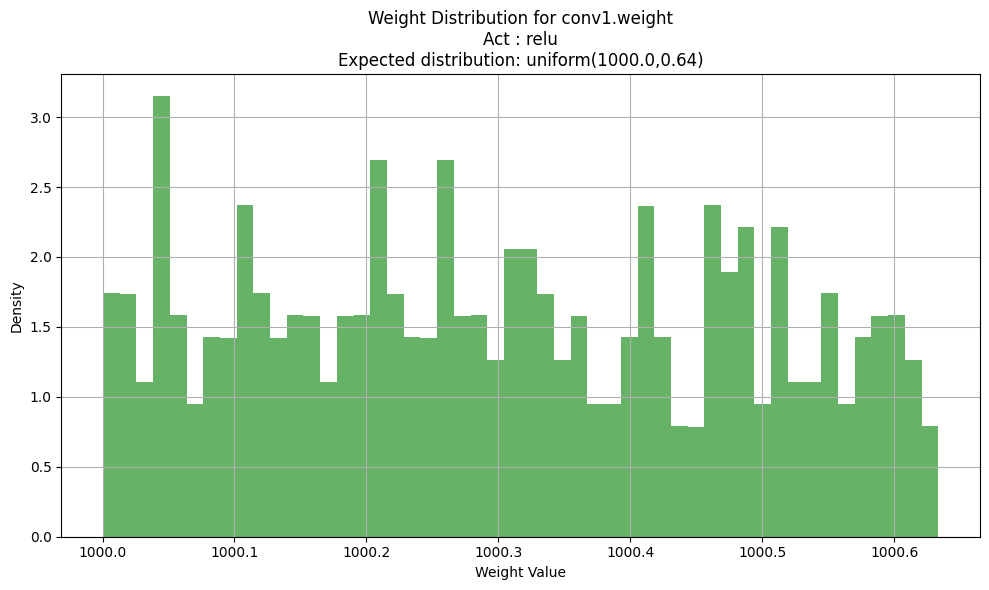

In [66]:
plot_weight_distribution(samples_new_first,
                        layer_of_interest,
                        module_of_interest,
                        model_config['activation'],
                        model_config['prior'],
                        pyro.get_param_store()['AutoUniform.lows.conv1.weight'][0][0][0][0].cpu().detach().numpy(),
                        pyro.get_param_store()['AutoUniform.widths.conv1.weight'][0][0][0][0].cpu().detach().numpy())

In [ ]:
samples_new_first